# Seoul Bike Sharing Demand

**Amelia Jiang-Yu** · ajiangy1@jhu.edu &nbsp;&nbsp;|&nbsp;&nbsp; **Raj Gosain** · rgosain@jhu.edu

EN.553.414/614 ASDA II

---

## Table of Contents

- [0. Introduction](#0-introduction)
  - [a. Dataset Description](#a-dataset-description)
  - [b. Data Visualisation](#b-data-visualisation)
  - [c. Descriptive Statistics](#c-descriptive-statistics)
- [1. Best Normal Linear Model](#1-best-normal-linear-model)
  - [a. Fitting the Model](#a-fitting-the-model)
  - [b. Model Interpretation](#b-model-interpretation)
  - [c. Diagnostics](#c-model-diagnostics)
  - [d. Strengths & Limitations](#d-model-strengths-and-limitations)
- [2. Simplest Linear Model](#2-simplest-linear-model)
  - [a. Fitting the Model](#a-fitting-the-model-1)
  - [b. Model Interpretation](#b-model-interpretation-1)
  - [c. Strengths & Limitations](#c-model-strengths-and-limitations)
- [3. Generalised Linear Models (GLMs)](#3-generalised-linear-models-glms)
  - [a. Fitting the Model](#a-fitting-the-model-2)
  - [b. Comparison to Previous Models](#b-comparison-to-previous-models)
  - [c. Model Interpretation](#c-model-interpretation)
  - [d. Diagnostics](#d-model-diagnostics)


---
## 0. Introduction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")

### a. Dataset Description

**Source:** [UCI Machine Learning Repository — Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand)

The dataset records hourly bike rental counts from the Seoul public bike-sharing system over a full year (December 2017 – November 2018), yielding 8,760 hourly observations with 14 variables.

**Response variable:**
- `Rented Bike Count` — number of bikes rented in a given hour

**Explanatory variables:**

| Variable | Type | Description |
|---|---|---|
| `Date` | Categorical | Calendar date (365 unique days) |
| `Hour` | Categorical | Hour of day (0–23) |
| `Seasons` | Categorical | Spring, Summer, Autumn, Winter |
| `Holiday` | Binary | Public holiday or not |
| `Functioning Day` | Binary | Whether the system was operational |
| `Temperature (°C)` | Continuous | Air temperature |
| `Humidity (%)` | Continuous | Relative humidity |
| `Wind Speed (m/s)` | Continuous | Wind speed |
| `Visibility (10m)` | Continuous | Atmospheric visibility |
| `Dew Point Temperature (°C)` | Continuous | Dew point |
| `Solar Radiation (MJ/m²)` | Continuous | Solar radiation |
| `Rainfall (mm)` | Continuous | Hourly rainfall |
| `Snowfall (cm)` | Continuous | Hourly snowfall |

**Note:** Observations on non-functioning days (`Functioning Day = No`) are excluded from all models, as the system was not operational and no rentals were possible. This removes a small number of days from the dataset before modelling.


In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")
df['Hour'] = df['Hour'].astype('category')
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'].astype(str) + ':00', dayfirst=True)
df['Date_only'] = pd.to_datetime(df['Date'], dayfirst=True)

In [3]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = ['Date', 'Hour', 'Seasons']
binary_cols = ['Holiday', 'Functioning Day']

### b. Data Visualisation


#### Categorical Variables

The categorical variables are: `Date`, `Hour`, and `Seasons`. We plot the distribution of `Rented Bike Count` for each level.


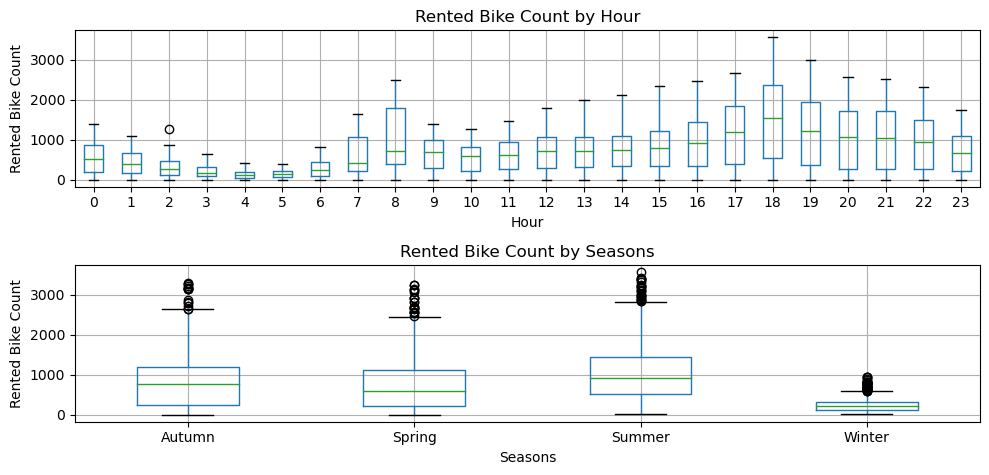

In [100]:
Y = 'Rented Bike Count'

cols_to_plot = categorical_cols[1:]

fig, axs = plt.subplots(len(cols_to_plot), 1, figsize=(10, 5))
axs = np.atleast_1d(axs)

for i, col in enumerate(cols_to_plot):
    if col != Y:
        df.boxplot(column=Y, by=col, ax=axs[i])
        axs[i].set_title(f'{Y} by {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)

plt.suptitle("")
plt.tight_layout()
plt.show()

`Rented Bike Count` shows a clear bimodal pattern by hour, with peaks at 8am (morning commute) and 6–7pm (evening commute), as well as a trough overnight. Demand is highest in Summer and lowest in Winter, consistent with wour prior beliefs on weather.

#### Continuous Variables

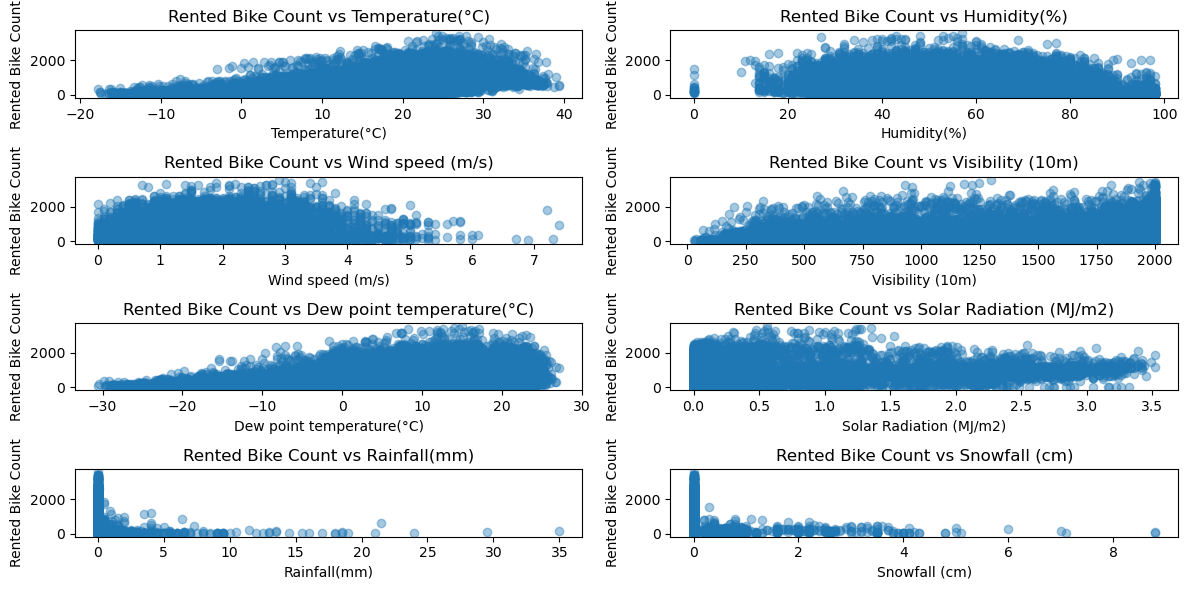

In [87]:
fig, axs = plt.subplots(4, 2, figsize=(12, 6))
axs = axs.flatten()
i = 0
for col in continuous_cols:
    if col != Y:
        axs[i].scatter(df[col], df[Y], alpha=0.4)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)
        axs[i].set_title(f'{Y} vs {col}')
        i += 1
plt.tight_layout()
plt.show()


#### Binary Variables

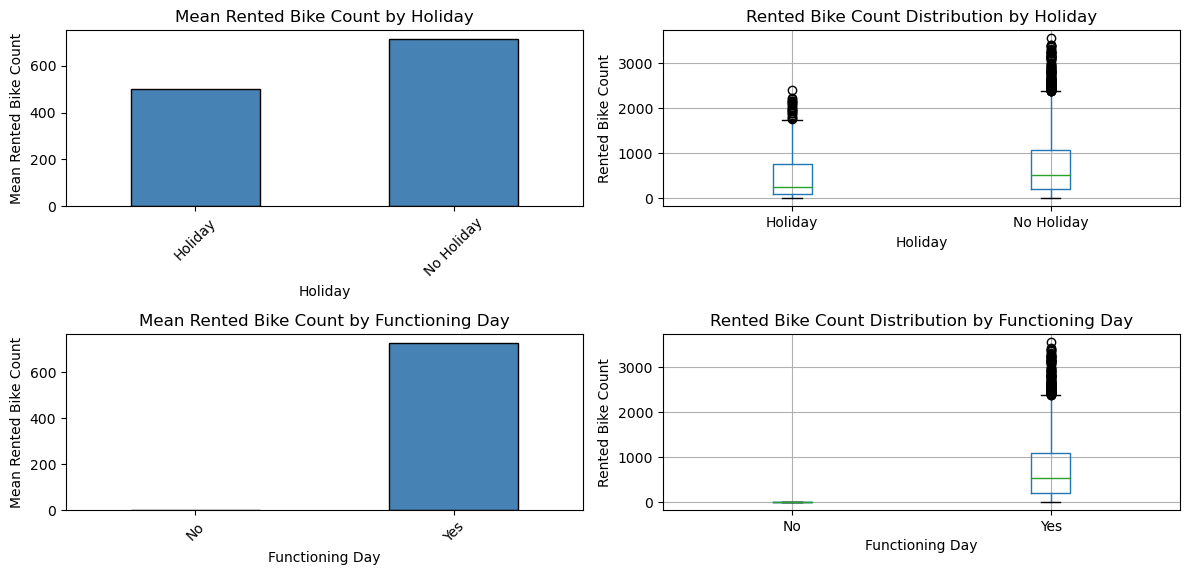

In [88]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.flatten()
i = 0
for col in binary_cols:
    if col != Y:
        prop = df.groupby(col)[Y].mean()
        prop.plot(kind='bar', color='steelblue', edgecolor='black', ax=axs[i])
        axs[i].set_title(f'Mean {Y} by {col}')
        axs[i].set_ylabel(f'Mean {Y}')
        axs[i].set_xlabel(col)
        axs[i].set_xticks(range(len(prop.index)))
        axs[i].set_xticklabels(prop.index.astype(str), rotation=45)
        i += 1
        df.boxplot(column=Y, by=col, ax=axs[i])
        axs[i].set_title(f'{Y} Distribution by {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)
        plt.suptitle("")
        i += 1
plt.tight_layout()
plt.show()


`Rented Bike Count` is consistently higher on non-holiday days, most likely because commuting demand  drops on public holidays. Functioning Day shows the expected pattern, but since all non-functioning days are removed from the modelling dataset, this variable is dropped.

### c. Descriptive Statistics


#### Categorical Variables


In [89]:
df[categorical_cols].describe(include='all')


,Date,Hour,Seasons
count,8760,8760,8760
unique,365,24,4
top,01/12/2017,0,Spring
freq,24,365,2208


With 365 unique dates the dataset spans exactly one full year. There are 24 unique hours and 4 seasons, each appearing the expected number of times.

#### Continuous Variables


In [90]:
df[continuous_cols].describe(include='all')


,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


Mean `Rented Bike Count` is 704.6, with a minimum of 0 and a maximum of 3,556. The standard deviation (approximately 1,000) is larger than the mean, which is an early indication of overdispersion. Temperature ranges from −17.8°C to 39.4°C.

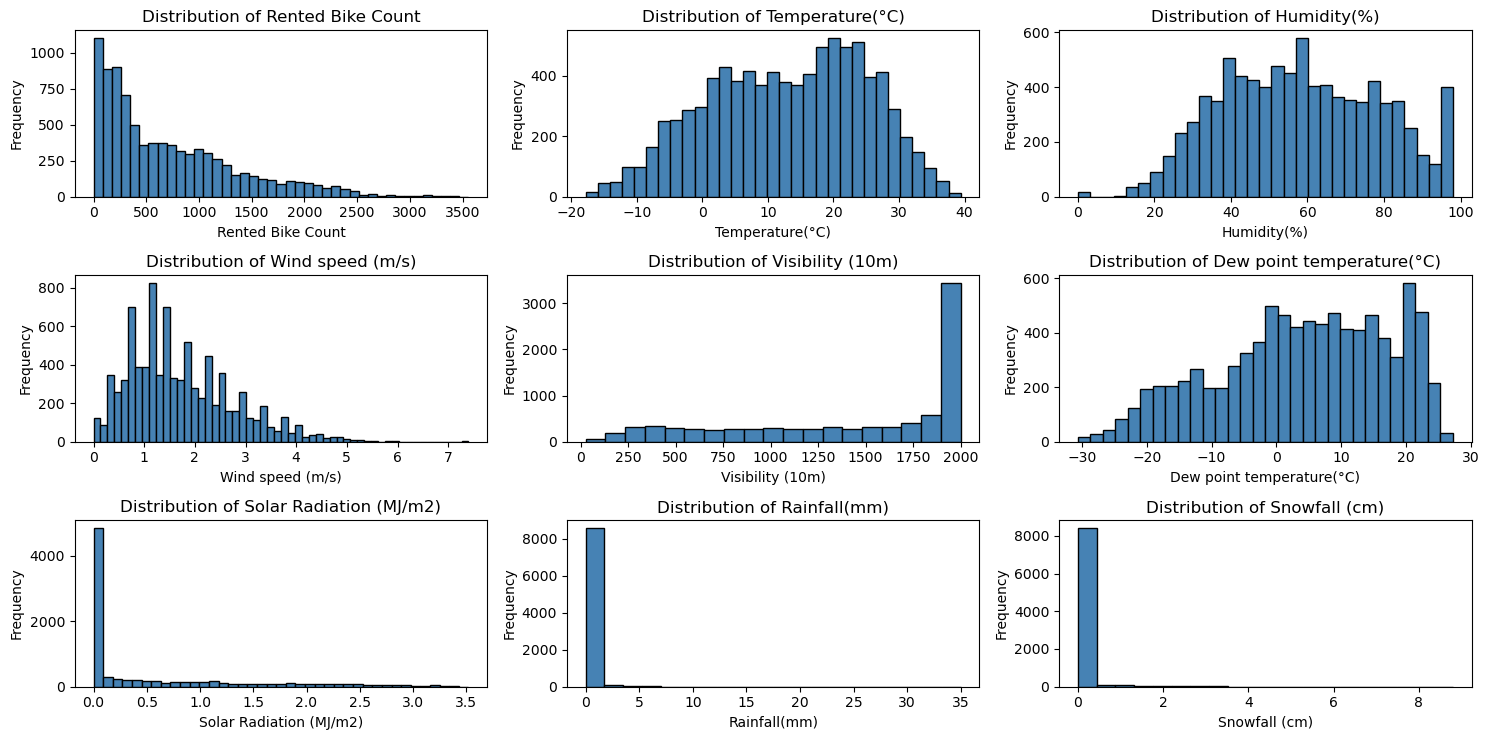

In [91]:
fig, axs = plt.subplots(3, 3, figsize=(15, 7.5))
axs = axs.flatten()
for i, col in enumerate(continuous_cols):
    q75, q25 = np.percentile(df[col].dropna(), [75, 25])
    iqr = q75 - q25
    n = df[col].dropna().shape[0]
    bin_width = 2 * iqr / (n ** (1/3)) if iqr > 0 else None
    bins = int((df[col].max() - df[col].min()) / bin_width) if bin_width else 20
    axs[i].hist(df[col], bins=bins, edgecolor='black', color='steelblue')
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


`Rented Bike Count` is right-skewed and violates the normality assumption of OLS. `Temperature` and `Dew Point Temperature` appear roughly normal. `Rainfall` and `Snowfall` are heavily zero inflated. This distributional evidence further motivates the use of a count-data GLM.


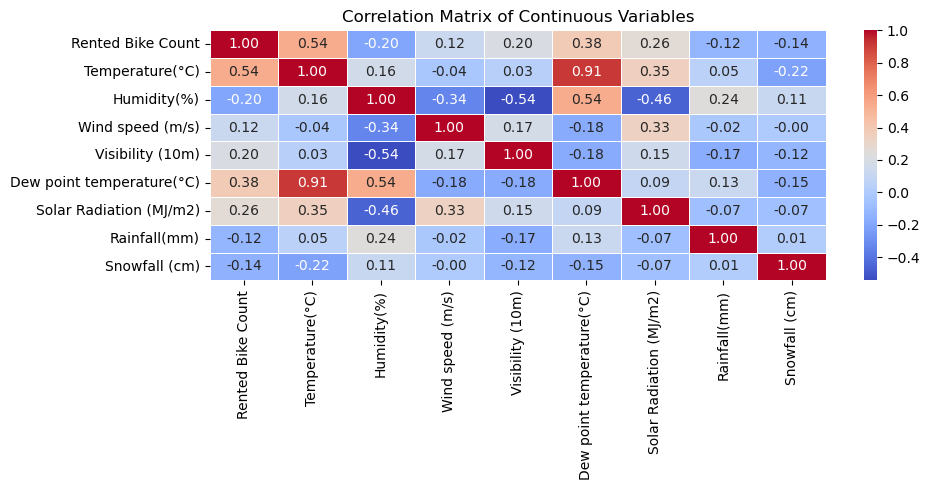

In [101]:
corr_matrix = df[continuous_cols].corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()


`Rented Bike Count` shows its strongest positive correlation with `Temperature` (r ≈ 0.54) and `Dew Point Temperature` (r ≈ 0.38), and its strongest negative correlation with `Humidity` (r ≈ −0.20). `Wind Speed` and `Visibility` show weak correlations with the response.


---
## 1. Best Normal Linear Model

We fit an Ordinary Least Squares (OLS) regression model to the data. We first fit a full model with all available predictors to establish a performance baseline, then apply forward and backward AIC-based feature selection to identify the most parsimonious model. All-hours dummy variables are included to capture the strong hourly pattern observed in the EDA.


In [46]:
df_model = df.copy()
bad_dates = df_model.loc[df_model['Functioning Day'] == 'No', 'Date'].unique()
df_model = df_model[~df_model['Date'].isin(bad_dates)].copy()
df_model = df_model.drop(columns=['Functioning Day'])


In [47]:
df_model['Weekend'] = (pd.to_datetime(df_model['Date']).dt.dayofweek >= 5).astype(int)
df_encoded = pd.get_dummies(
    df_model.drop(['Date', 'DateTime', 'Date_only'], axis=1),
    columns=['Seasons', 'Holiday', 'Hour'],
    drop_first=True,
    dtype=int
)


In [48]:
X_all = df_encoded.drop(columns=['Rented Bike Count'])
Y = df_encoded['Rented Bike Count']

### a. Fitting the Model


#### Full Model (All Predictors)

As a baseline we fit OLS with all explanatory variables included (after one-hot encoding of categorical variables). This gives us a reference R² and AIC against which to compare the feature-selected model.


In [76]:
X_all = sm.add_constant(X_all)
model_all = sm.OLS(Y, X_all).fit()

In [77]:
all_Y_pred = model_all.predict(X_all)
all_mse = mean_squared_error(Y, all_Y_pred)
all_r2 = r2_score(Y, all_Y_pred)
print(f'MSE  : {all_mse:.2f}')
print(f'RMSE : {np.sqrt(all_mse):.2f}')
print(f'R²   : {all_r2:.4f}')


MSE  : 139136.64
RMSE : 373.01
R²   : 0.6624


In [78]:
hour_dummies = pd.get_dummies(df_model['Hour'], prefix='Hour', drop_first=True, dtype=int)
df_model = pd.concat([df_model, hour_dummies], axis=1)
hour_terms = list(hour_dummies.columns)

target = 'Q("Rented Bike Count")'
candidate_terms = hour_terms + [
    'Q("Temperature(°C)")', 'I(Q("Temperature(°C)")**2)', 'Q("Humidity(%)")',
    'Q("Wind speed (m/s)")', 'Q("Visibility (10m)")', 'Q("Dew point temperature(°C)")',
    'Q("Solar Radiation (MJ/m2)")', 'Q("Rainfall(mm)")', 'Q("Snowfall (cm)")',
    'C(Seasons)', 'C(Holiday)', 'C(Weekend)'
]


In [79]:
selected_terms = []
remaining_terms = candidate_terms.copy()
current_aic = np.inf

while remaining_terms:
    candidate_results = []
    for term in remaining_terms:
        formula = f'{target} ~ ' + ' + '.join(selected_terms + [term])
        model = smf.ols(formula=formula, data=df_model).fit()
        candidate_results.append((model.aic, term))
    best_new_aic, best_term = min(candidate_results)
    if best_new_aic >= current_aic:
        break
    selected_terms.append(best_term)
    remaining_terms.remove(best_term)
    current_aic = best_new_aic

forward_ols_model = smf.ols(formula=f'{target} ~ ' + ' + '.join(selected_terms), data=df_model).fit()
forward_selected_terms = selected_terms.copy()


In [80]:
selected_terms = candidate_terms.copy()
current_model = smf.ols(formula=f'{target} ~ ' + ' + '.join(selected_terms), data=df_model).fit()
current_aic = current_model.aic

while len(selected_terms) > 1:
    candidate_results = []
    for term in selected_terms:
        trial_terms = [t for t in selected_terms if t != term]
        try:
            model = smf.ols(formula=f'{target} ~ ' + ' + '.join(trial_terms), data=df_model).fit()
            candidate_results.append((model.aic, term, model, trial_terms))
        except:
            continue
    if not candidate_results:
        break
    best_new_aic, removed_term, best_model, best_terms = min(candidate_results)
    if best_new_aic >= current_aic:
        break
    selected_terms, current_model, current_aic = best_terms, best_model, best_new_aic

backward_ols_model = smf.ols(formula=f'{target} ~ ' + ' + '.join(selected_terms), data=df_model).fit()
backward_selected_terms = selected_terms.copy()


In [95]:
def clean_terms(terms):
    pretty = []
    for t in terms:
        if t.startswith("Hour_"):
            pretty.append(f"Hour = {int(t.replace('Hour_', ''))}")
            continue
        t = re.sub(r'Q\("(.+?)"\)', r'\1', t)
        t = t.replace('I(Q("Temperature(°C)")**2)', 'Temperature²')
        t = re.sub(r'C\((.+?)\)', r'\1', t)
        pretty.append(t)
    pretty = list(dict.fromkeys(pretty))
    pretty = sorted(pretty, key=lambda x: (not x.startswith("Hour"), x if not x.startswith("Hour") else int(x.split("=")[1])))
    return pretty

def build_formula_md(terms, title, aic):
    md = f"### {title}\n\n**AIC:** {aic:.2f}\n\n**Selected Model:**\n\n`Rented Bike Count` ~\n"
    for i, t in enumerate(terms):
        md += f"&nbsp;&nbsp;&nbsp;&nbsp;`{t}`" + (" +\n" if i < len(terms) - 1 else "")
    return md

forward_clean = clean_terms(forward_selected_terms)
backward_clean = clean_terms(backward_selected_terms)

forward_only = sorted(set(forward_clean) - set(backward_clean))
backward_only = sorted(set(backward_clean) - set(forward_clean))
diff_md = "### Feature Differences\n\n"
if not forward_only and not backward_only:
    diff_md += "Both procedures selected the same features."
else:
    if forward_only:
        diff_md += "**Forward Only:**\n\n" + "".join(f"- `{t}`\n" for t in forward_only) + "\n"
    if backward_only:
        diff_md += "**Backward Only:**\n\n" + "".join(f"- `{t}`\n" for t in backward_only)

display(Markdown(build_formula_md(forward_clean, "Forward Selection Model", forward_ols_model.aic)))

### Forward Selection Model

**AIC:** 124064.40

**Selected Model:**

`Rented Bike Count` ~
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 1` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 2` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 3` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 4` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 5` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 6` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 7` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 8` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 9` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 10` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 11` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 12` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 13` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 14` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 15` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 16` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 17` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 18` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 19` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 20` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 21` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 22` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 23` +
&nbsp;&nbsp;&nbsp;&nbsp;`Dew point temperature(°C)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Holiday` +
&nbsp;&nbsp;&nbsp;&nbsp;`Humidity(%)` +
&nbsp;&nbsp;&nbsp;&nbsp;`I(Temperature(°C)**2)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Rainfall(mm)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Seasons` +
&nbsp;&nbsp;&nbsp;&nbsp;`Snowfall (cm)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Solar Radiation (MJ/m2)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Temperature(°C)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Visibility (10m)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Weekend`

In [93]:
display(Markdown(build_formula_md(backward_clean, "Backward Selection Model", backward_ols_model.aic)
                 + "\n\n---\n\n" + diff_md))


### Backward Selection Model

**AIC:** 124062.44

**Selected Model:**

`Rented Bike Count` ~
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 1` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 2` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 3` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 4` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 5` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 6` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 7` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 8` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 10` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 11` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 12` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 13` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 14` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 15` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 17` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 18` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 19` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 20` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 21` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 22` +
&nbsp;&nbsp;&nbsp;&nbsp;`Hour = 23` +
&nbsp;&nbsp;&nbsp;&nbsp;`Dew point temperature(°C)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Holiday` +
&nbsp;&nbsp;&nbsp;&nbsp;`Humidity(%)` +
&nbsp;&nbsp;&nbsp;&nbsp;`I(Temperature(°C)**2)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Rainfall(mm)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Seasons` +
&nbsp;&nbsp;&nbsp;&nbsp;`Snowfall (cm)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Solar Radiation (MJ/m2)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Temperature(°C)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Visibility (10m)` +
&nbsp;&nbsp;&nbsp;&nbsp;`Weekend`

---

### Feature Differences

**Forward Only:**

- `Hour = 16`
- `Hour = 9`



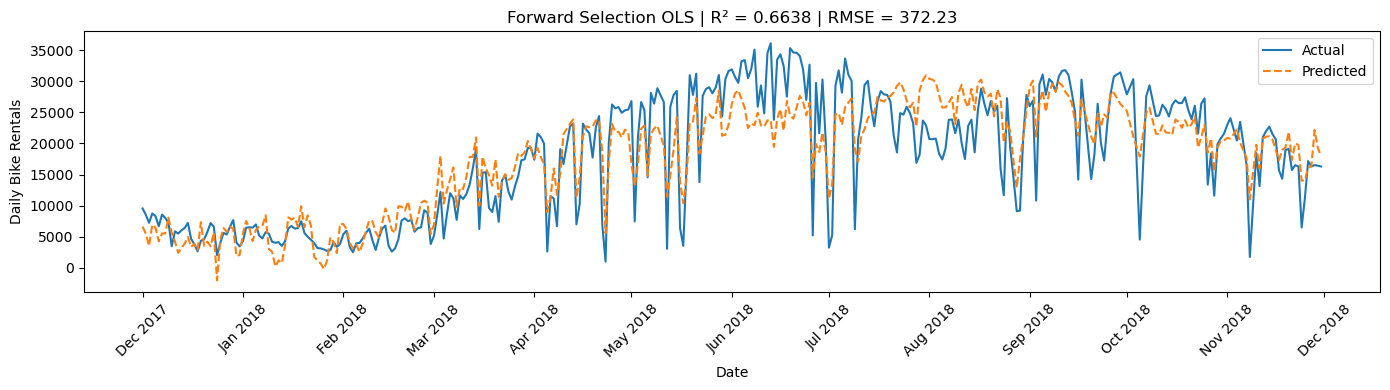

MSE  : 138554.14
RMSE : 372.23
R²   : 0.6638


In [82]:
forward_Y_pred = forward_ols_model.predict(df_model)
Y = df_model['Rented Bike Count']
forward_mse = mean_squared_error(Y, forward_Y_pred)
forward_r2 = r2_score(Y, forward_Y_pred)

forward_daily = (pd.DataFrame({'Date': df_model['Date_only'], 'Actual': Y, 'Predicted': forward_Y_pred})
                 .groupby('Date')[['Actual', 'Predicted']].sum().reset_index().sort_values('Date'))
forward_daily['Date'] = pd.to_datetime(forward_daily['Date'])

plt.figure(figsize=(14, 4))
plt.plot(forward_daily['Date'], forward_daily['Actual'], label='Actual')
plt.plot(forward_daily['Date'], forward_daily['Predicted'], linestyle='--', label='Predicted')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title(f'Forward Selection OLS | R² = {forward_r2:.4f} | RMSE = {np.sqrt(forward_mse):.2f}')
plt.xlabel("Date")
plt.ylabel("Daily Bike Rentals")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'MSE  : {forward_mse:.2f}')
print(f'RMSE : {np.sqrt(forward_mse):.2f}')
print(f'R²   : {forward_r2:.4f}')


In [110]:
print(forward_ols_model.summary().tables[0])

                              OLS Regression Results                              
Dep. Variable:     Q("Rented Bike Count")   R-squared:                       0.664
Model:                                OLS   Adj. R-squared:                  0.662
Method:                     Least Squares   F-statistic:                     461.4
Date:                    Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                            21:07:28   Log-Likelihood:                -61995.
No. Observations:                    8448   AIC:                         1.241e+05
Df Residuals:                        8411   BIC:                         1.243e+05
Df Model:                              36                                         
Covariance Type:                nonrobust                                         


In [111]:
print(forward_ols_model.summary().tables[1])

                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                       1120.8651     86.541     12.952      0.000     951.224    1290.506
C(Seasons)[T.Spring]            -162.7034     12.178    -13.360      0.000    -186.575    -138.831
C(Seasons)[T.Summer]            -123.2837     16.650     -7.405      0.000    -155.921     -90.646
C(Seasons)[T.Winter]            -321.6168     18.464    -17.418      0.000    -357.811    -285.422
C(Holiday)[T.No Holiday]         130.5300     19.210      6.795      0.000      92.874     168.186
C(Weekend)[T.1]                  -46.4886      8.994     -5.169      0.000     -64.118     -28.859
Q("Temperature(°C)")              13.3263      3.305      4.032      0.000       6.848      19.804
Q("Humidity(%)")                 -10.7938      0.904    -11.935      0.000     -12.567      -9.021
Hour_18   

#### Why This Is the Best Model

Both forward and backward AIC selection converge on the nearly same set of predictors, with both excluding Visibility. Backward selection also ignores Hours 9 and 16. Since forward selection has a slightly lower AIC, even though it includes these extra two predictors, we chose it as our best linear model.

The selected model includes:
- All 23 hour dummies
- Temperature and Temperature²
- Dew Point Temperature, Humidity, Solar Radiation, Rainfall, Snowfall, Visibility
- Season
- Holiday and Weekend


### b. Model Interpretation

The forward-selected OLS model includes seasonal indicators, weather variables, and hour-of-day effects. The model explains a substantial portion of the variability in bike rentals, with an \(R^2\) of 0.664 and an adjusted \(R^2\) of 0.662.

Temperature has a positive coefficient, while the quadratic temperature term is negative, indicating that bike demand increases as temperatures become more comfortable but declines during very hot conditions.

The strongest predictors are the hour-of-day indicators. Relative to midnight, the largest positive effects occur during commuting hours, particularly at 8 AM and 6–7 PM, confirming the expected morning and evening peaks in ridership.

Humidity and rainfall both have negative coefficients, showing that poor weather reduces demand. Non-holidays are associated with higher rental counts, while weekends have slightly lower usage after accounting for weather and time-of-day effects.

Overall, the model captures the main patterns in the data well, especially the effects of commuting behavior and weather conditions.

### c. Model Diagnostics


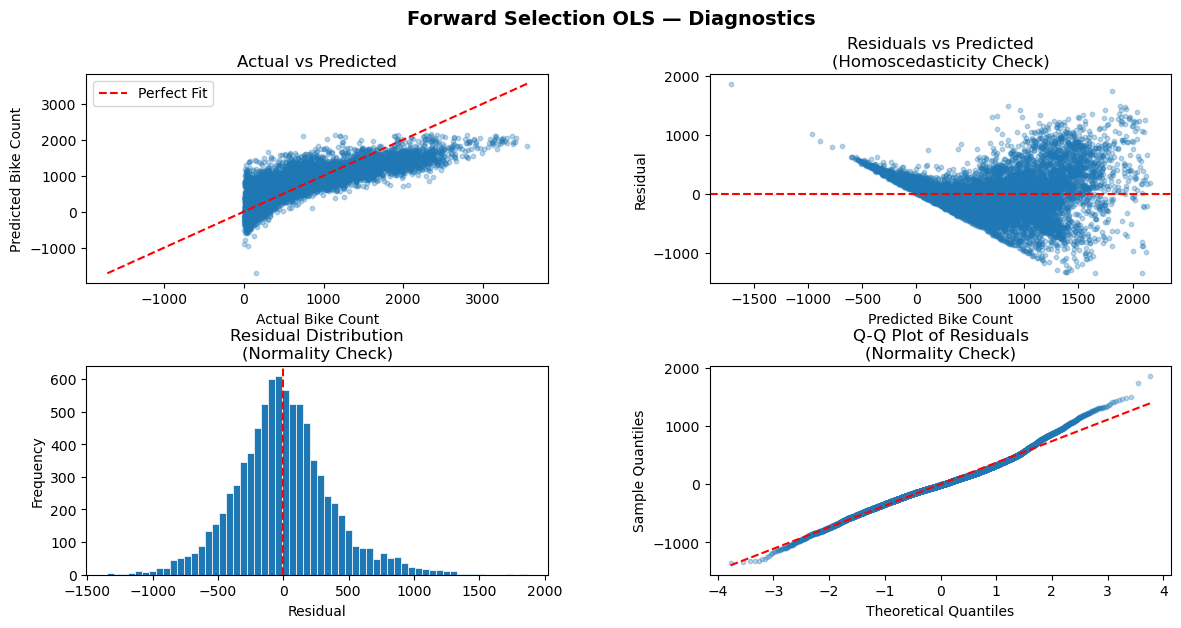

In [74]:
Y = df_model['Rented Bike Count'].astype(float)
forward_residuals = Y - forward_Y_pred
forward_residuals = Y - forward_Y_pred
fig = plt.figure(figsize=(14, 6.5))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(Y, forward_Y_pred, alpha=0.3, s=10)
lims = [min(Y.min(), forward_Y_pred.min()), max(Y.max(), forward_Y_pred.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
ax1.set_xlabel('Actual Bike Count')
ax1.set_ylabel('Predicted Bike Count')
ax1.set_title('Actual vs Predicted')
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(forward_Y_pred, forward_residuals, alpha=0.3, s=10)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted Bike Count')
ax2.set_ylabel('Residual')
ax2.set_title('Residuals vs Predicted\n(Homoscedasticity Check)')

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(forward_residuals, bins=60, edgecolor='white', linewidth=0.5)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Residual')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution\n(Normality Check)')

ax4 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(forward_residuals, dist='norm')
ax4.scatter(osm, osr, alpha=0.3, s=10)
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')
ax4.set_title('Q-Q Plot of Residuals\n(Normality Check)')

plt.suptitle('Forward Selection OLS — Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The diagnostic plots indicate several important violations of the standard OLS assumptions.

The actual versus predicted plot shows that the model captures the overall trend in bike rentals, but it tends to underpredict during periods of very high demand. This suggests that the linear model has difficulty modeling extreme peak-hour counts.

The residuals versus predicted plot exhibits a clear funnel shape, with the spread of residuals increasing as the fitted values grow. This indicates heteroscedasticity, meaning the error variance is not constant across observations.

The residual histogram and Q-Q plot both show departures from normality, particularly in the tails, where large positive and negative residuals occur more frequently than expected under a normal distribution.

These results indicate that, although the OLS model explains a substantial portion of the variability in bike rentals, its assumptions are not fully satisfied. Because bike rentals are nonnegative count data with increasing variance at larger counts, a generalized linear model is likely to provide a more appropriate framework.

### d. Model Strengths and Limitations

The forward-selected OLS model is easy to interpret and provides a strong baseline. Its coefficients clearly quantify how weather, season, and hour-of-day affect bike demand, and the AIC-based feature selection procedure yields a relatively parsimonious model that still explains a substantial amount of variation in the data.

However, several limitations remain. Because the response is a count variable, the model can produce negative predictions, which are not meaningful in practice. The diagnostic plots also reveal heteroscedasticity and non-normal residuals, indicating that the standard OLS assumptions are violated. In addition, some predictors, such as temperature and dew point temperature, are highly correlated, which may make individual coefficient estimates less stable.

Overall, the model captures the major drivers of bike rentals and performs reasonably well, but its assumptions are not well suited to count data. These shortcomings motivate the use of generalized linear models in the next section.

---
## 2. Simplest Linear Model

The simplest defensible model uses a one continuous predictor. From the EDA, `Temperature` has the strongest linear correlation with `Rented Bike Count` (r ≈ 0.54) and a clear positive relationship visible in the scatter plot. It makes sense that temperature outside impacts how many people rent bikes 

### a. Fitting the Model

We fit a simple OLS regression of `Rented Bike Count` on `Temperature (°C)` only:

$$\hat{Y} = \beta_0 + \beta_1 \cdot T$$


#### Model Output


In [113]:
X_simple = sm.add_constant(df_model['Temperature(°C)'])
Y = df_encoded['Rented Bike Count']
model_simple = sm.OLS(Y, X_simple).fit()
summary = model_simple.summary()

print(summary.tables[0])

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     3923.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        21:07:48   Log-Likelihood:                -64989.
No. Observations:                8448   AIC:                         1.300e+05
Df Residuals:                    8446   BIC:                         1.300e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         


In [114]:
print(summary.tables[1])

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             347.8847      8.384     41.492      0.000     331.449     364.320
Temperature(°C)    29.8479      0.477     62.631      0.000      28.914      30.782


In [54]:
simple_Y_pred = model_simple.predict(X_simple)
simple_mse = mean_squared_error(Y, simple_Y_pred)
simple_r2 = r2_score(Y, simple_Y_pred)
print(f'MSE  : {simple_mse:.2f}')
print(f'RMSE : {np.sqrt(simple_mse):.2f}')
print(f'R²   : {simple_r2:.4f}')


MSE  : 281440.61
RMSE : 530.51
R²   : 0.3171


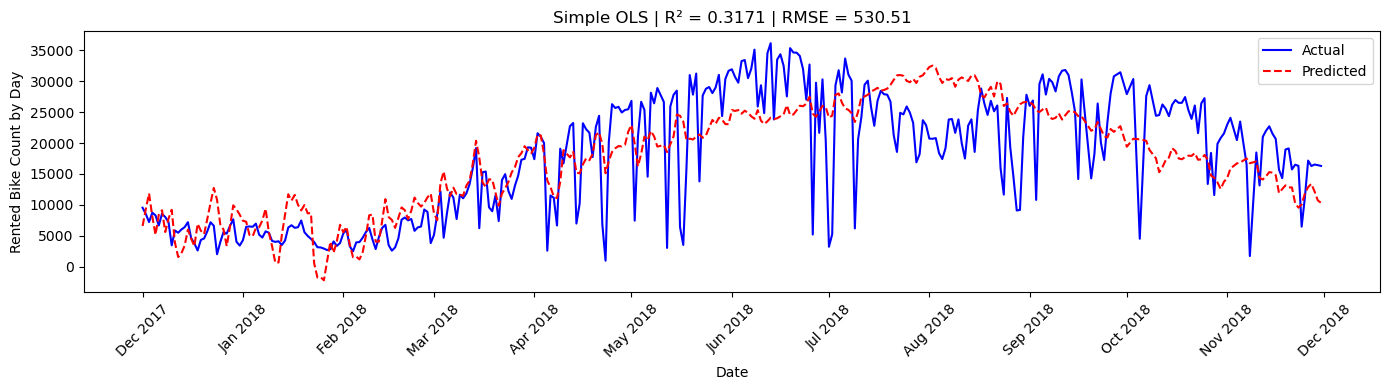

In [71]:
simple_daily = (pd.DataFrame({'Date': df_model['Date_only'], 'Actual': Y, 'Predicted': simple_Y_pred})
                .groupby('Date')[['Actual', 'Predicted']].sum().reset_index().sort_values('Date'))

plt.figure(figsize=(14, 4))
plt.plot(simple_daily['Date'], simple_daily['Actual'], label='Actual', color='blue')
plt.plot(simple_daily['Date'], simple_daily['Predicted'], label='Predicted', color='red', linestyle='--')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title(f"Simple OLS | R² = {simple_r2:.4f} | RMSE = {np.sqrt(simple_mse):.2f}")
plt.xlabel("Date")
plt.ylabel("Rented Bike Count by Day")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### b. Model Interpretation

The simple linear model uses temperature as the sole predictor of bike rentals. The estimated temperature coefficient is positive, indicating that warmer weather is associated with higher bike demand. On average, each 1°C increase in temperature corresponds to an increase in expected rentals.

The fitted line captures the broad seasonal trend: rentals are lower during the winter months, rise steadily through spring, peak during the summer, and decline again in the fall. This confirms that temperature is an important driver of bike usage.

However, the model explains only a modest portion of the variation in the data, with an \(R^2\) of 0.317. This means that temperature alone accounts for about 32% of the variability in daily bike rentals. The RMSE of 530.51 rentals per day indicates substantial prediction error, reflecting the fact that many other factors—such as hour of day, season, holidays, and precipitation—also play important roles.

### c. Model Strengths and Limitations

The simple linear model is highly interpretable and provides a clear description of the relationship between temperature and bike rentals. With only one predictor, the model is easy to explain and serves as a useful baseline for comparison with more sophisticated models.

Its main limitation is that temperature alone explains only a modest portion of the variability in bike demand. Important factors such as hour of day, season, holidays, and precipitation are omitted, leading to relatively poor predictive performance. Like all ordinary least squares models, it can also produce negative predictions and relies on assumptions that are not well suited to count data.

Overall, the simple model is valuable for illustrating the strong positive association between temperature and bike usage, but it is too limited to provide accurate predictions on its own.

---
## 3. Generalized Linear Models (GLMs)

The response variable, `Rented Bike Count`, is a count variable and does not satisfy the assumptions of ordinary least squares regression. The data are nonnegative, right-skewed, and exhibit increasing variance as the mean grows. These characteristics suggest that a count-based generalized linear model is more appropriate.

We consider two standard models for count data:

1. Poisson GLM, which assumes that the mean and variance are equal.
2. Negative Binomial GLM, which allows the variance to exceed the mean.

Both models have predictors act multiplicatively on the expected number of bike rentals. Exponentiating the coefficients allows us to describe the proportional change in expected rentals associated with a one-unit increase in a predictor.

Because the bike rental data show substantial overdispersion, we expect the Negative Binomial model to provide a better fit than the Poisson model.

### a. Fitting the Model

We fit both Poisson and Negative Binomial generalized linear models using the same set of predictors as the best OLS model. To assess whether the Poisson model is appropriate, we compute the Pearson dispersion statistic,

$$
\hat{\phi} = \frac{\chi_P^2}{df}.
$$

Values much larger than 1 indicate overdispersion, meaning the variance exceeds the mean and the Poisson model is not suitable. In that case, the Negative Binomial model is preferred because it explicitly accounts for the extra variability in the data.

In [106]:
df_glm = df.copy()
bad_dates_glm = df_glm.loc[df_glm['Functioning Day'] == 'No', 'Date'].unique()
df_glm = df_glm[~df_glm['Date'].isin(bad_dates_glm)].copy()
df_glm = df_glm.drop(columns=['Functioning Day'])
df_glm['Weekend'] = (pd.to_datetime(df_glm['Date']).dt.dayofweek >= 5).astype(int)
df_glm['Sq Temp'] = df_glm['Temperature(°C)'] ** 2


In [107]:
formula = """
Q('Rented Bike Count') ~
C(Hour) +
Q('Temperature(°C)') +
Q('Humidity(%)') +
Q('Wind speed (m/s)') +
Q('Visibility (10m)') +
Q('Dew point temperature(°C)') +
Q('Solar Radiation (MJ/m2)') +
Q('Rainfall(mm)') +
Q('Snowfall (cm)') +
Q('Sq Temp') +
C(Seasons) +
C(Holiday) +
Weekend
"""


In [108]:
poisson_model = smf.glm(formula=formula, data=df_glm, family=sm.families.Poisson()).fit()

glm_pred = poisson_model.predict(df_glm)
poisson_mse = mean_squared_error(df_glm['Rented Bike Count'], glm_pred)
poisson_rmse = np.sqrt(poisson_mse)
poisson_r2 = r2_score(df_glm['Rented Bike Count'], glm_pred)
dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid

print(f"Poisson RMSE: {poisson_rmse:.2f}")
print(f"Poisson R²:   {poisson_r2:.4f}")
print(f"Dispersion:   {dispersion:.3f}")


Poisson RMSE: 283.29
Poisson R²:   0.8053
Dispersion:   1152136.914


In [116]:
nb_model = smf.glm(formula=formula, data=df_glm, family=sm.families.NegativeBinomial()).fit()
summary = nb_model.summary()
print(summary.tables[0])

                   Generalized Linear Model Regression Results                    
Dep. Variable:     Q('Rented Bike Count')   No. Observations:                 8448
Model:                                GLM   Df Residuals:                     8410
Model Family:            NegativeBinomial   Df Model:                           37
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -61116.
Date:                    Fri, 08 May 2026   Deviance:                       2419.6
Time:                            21:08:18   Pearson chi2:                 1.61e+03
No. Iterations:                       100   Pseudo R-squ. (CS):             0.5109
Covariance Type:                nonrobust                                         


In [117]:
print(summary.tables[1])

                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          7.9411      0.233     34.116      0.000       7.485       8.397
C(Hour)[T.1]                      -0.1613      0.076     -2.135      0.033      -0.309      -0.013
C(Hour)[T.2]                      -0.4660      0.076     -6.162      0.000      -0.614      -0.318
C(Hour)[T.3]                      -0.8523      0.076    -11.256      0.000      -1.001      -0.704
C(Hour)[T.4]                      -1.2491      0.076    -16.475      0.000      -1.398      -1.100
C(Hour)[T.5]                      -1.1981      0.076    -15.782      0.000      -1.347      -1.049
C(Hour)[T.6]                      -0.4849      0.076     -6.390      0.000      -0.634      -0.336
C(Hour)[T.7]                       0.2767      0.076      3.646      0.000       0.128       0.425
C(Hour)[T.

In [60]:
nb_pred = nb_model.predict(df_glm)
nb_rmse = np.sqrt(mean_squared_error(df_glm['Rented Bike Count'], nb_pred))
nb_r2 = r2_score(df_glm['Rented Bike Count'], nb_pred)
print(f"NB RMSE: {nb_rmse:.2f}")
print(f"NB R²:   {nb_r2:.4f}")


NB RMSE: 338.84
NB R²:   0.7214


### b. Comparison to Previous Models


In [61]:
print(f"{'Model':<22} {'MSE':>14} {'RMSE':>10} {'R²':>10}")
print("─" * 58)
print(f"{'Simple OLS':<22} {simple_mse:>14.2f} {np.sqrt(simple_mse):>10.2f} {simple_r2:>10.4f}")
print(f"{'Forward OLS':<22} {forward_mse:>14.2f} {np.sqrt(forward_mse):>10.2f} {forward_r2:>10.4f}")
print(f"{'Poisson GLM':<22} {poisson_mse:>14.2f} {poisson_rmse:>10.2f} {poisson_r2:>10.4f}")
print(f"{'Negative Binomial':<22} {nb_rmse**2:>14.2f} {nb_rmse:>10.2f} {nb_r2:>10.4f}")
print()
print(f"Poisson AIC:           {poisson_model.aic:.2f}")
print(f"Negative Binomial AIC: {nb_model.aic:.2f}")


Model                             MSE       RMSE         R²
──────────────────────────────────────────────────────────
Simple OLS                  281440.61     530.51     0.3171
Forward OLS                 138554.14     372.23     0.6638
Poisson GLM                  80251.95     283.29     0.8053
Negative Binomial           114811.57     338.84     0.7214

Poisson AIC:           920236.46
Negative Binomial AIC: 122307.93


The Poisson model achieves strong predictive performance, with an RMSE of 283.29 and an $R^2$ of 0.805. However, the Pearson dispersion statistic is extremely large ($\hat{\phi} \approx 1.15 \times 10^6$), indicating severe overdispersion. This means that the Poisson assumption that the variance equals the mean is clearly violated, so its standard errors and confidence intervals are not reliable.

The Negative Binomial model addresses this issue by allowing the variance to exceed the mean. Although its RMSE (338.84) and $R^2$ (0.721) are slightly worse than the Poisson model, it provides a much more appropriate statistical framework for the data and yields a substantially lower AIC (122,307.93).

Overall, the Negative Binomial model is preferred because it respects the count nature of the response, accounts for overdispersion, and avoids the unrealistic assumptions of both OLS and Poisson regression.

### c. Model Interpretation

In the Negative Binomial model, coefficients are estimated on the log scale. Exponentiating a coefficient converts it to a multiplicative effect on the expected number of bike rentals. For example, a value of 1.10 indicates that the expected count increases by 10%, while a value of 0.90 indicates a 10% decrease, holding all other variables constant.

The 95% confidence intervals are computed as

$$
\exp\left(\hat{\beta} \pm 1.96 \cdot \mathrm{SE}(\hat{\beta})\right).
$$

The table below reports these multiplicative effects and their confidence intervals. The accompanying coefficient plot summarizes the percentage increase or decrease in expected rentals associated with each predictor.

In [119]:
# Cell 1: Setup (run once)

ci = nb_model.conf_int()
params = nb_model.params
pvals = nb_model.pvalues

def effect_line(label, key, ref=None):
    b, (lo, hi) = params[key], ci.loc[key]

    # Convert from log-scale coefficients to multiplicative effects
    effect = np.exp(b)
    effect_lo = np.exp(lo)
    effect_hi = np.exp(hi)

    # Percentage change in expected rentals
    pct = (effect - 1) * 100

    ref_str = f" (vs. {ref})" if ref else ""
    sig = "*" if pvals[key] < 0.05 else "(ns)"

    return (
        f"- **{label}**{ref_str}: "
        f"{effect:.2f}× change in expected rentals "
        f"(95% CI [{effect_lo:.2f}, {effect_hi:.2f}]) "
        f"→ {pct:+.0f}% {sig}"
    )

In [120]:
# Cell 2: Weather Effects

weather_lines = [
    "### Weather",
    effect_line("Temperature (+1°C)", "Q('Temperature(°C)')"),
    effect_line("Humidity (+1%)", "Q('Humidity(%)')"),
    effect_line("Dew Point (+1°C)", "Q('Dew point temperature(°C)')"),
    effect_line("Solar Radiation (+1 MJ/m²)", "Q('Solar Radiation (MJ/m2)')"),
    effect_line("Rainfall (+1 mm)", "Q('Rainfall(mm)')"),
    effect_line("Snowfall (+1 cm)", "Q('Snowfall (cm)')")
]

display(Markdown("\n".join(weather_lines)))

### Weather
- **Temperature (+1°C)**: 1.00× change in expected rentals (95% CI [0.98, 1.02]) → -0% (ns)
- **Humidity (+1%)**: 0.97× change in expected rentals (95% CI [0.97, 0.98]) → -3% *
- **Dew Point (+1°C)**: 1.07× change in expected rentals (95% CI [1.05, 1.09]) → +7% *
- **Solar Radiation (+1 MJ/m²)**: 1.11× change in expected rentals (95% CI [1.05, 1.17]) → +11% *
- **Rainfall (+1 mm)**: 0.97× change in expected rentals (95% CI [0.95, 0.99]) → -3% *
- **Snowfall (+1 cm)**: 0.96× change in expected rentals (95% CI [0.91, 1.01]) → -4% (ns)

In [121]:
# Cell 3: Seasonal Effects

season_lines = [
    "### Season (reference: Autumn)",
    effect_line("Spring", "C(Seasons)[T.Spring]", ref="Autumn"),
    effect_line("Summer", "C(Seasons)[T.Summer]", ref="Autumn"),
    effect_line("Winter", "C(Seasons)[T.Winter]", ref="Autumn")
]

display(Markdown("\n".join(season_lines)))

### Season (reference: Autumn)
- **Spring** (vs. Autumn): 0.77× change in expected rentals (95% CI [0.73, 0.83]) → -23% *
- **Summer** (vs. Autumn): 0.90× change in expected rentals (95% CI [0.83, 0.99]) → -10% *
- **Winter** (vs. Autumn): 0.55× change in expected rentals (95% CI [0.50, 0.61]) → -45% *

In [118]:
# Cell 4: Holiday and Weekend Effects

other_lines = [
    "### Other",
    effect_line("Non-Holiday", "C(Holiday)[T.No Holiday]", ref="Holiday"),
    effect_line("Weekend", "Weekend", ref="Weekday")
]

display(Markdown("\n".join(other_lines)))

### Other
- **Non-Holiday** (vs. Holiday): 1.32× change in expected rentals (95% CI [1.19, 1.46]) → +32% *
- **Weekend** (vs. Weekday): 0.96× change in expected rentals (95% CI [0.91, 1.00]) → -4% (ns)

In [122]:
# Cell 5: Hour-of-Day Effects

hour_lines = [
    "### Hour — Peaks and Troughs (reference: Midnight)",
    effect_line("8 AM", "C(Hour)[T.8]", ref="Midnight"),
    effect_line("6 PM", "C(Hour)[T.18]", ref="Midnight"),
    effect_line("7 PM", "C(Hour)[T.19]", ref="Midnight"),
    effect_line("4 AM", "C(Hour)[T.4]", ref="Midnight"),
    effect_line("5 AM", "C(Hour)[T.5]", ref="Midnight")
]

display(Markdown("\n".join(hour_lines)))

### Hour — Peaks and Troughs (reference: Midnight)
- **8 AM** (vs. Midnight): 2.17× change in expected rentals (95% CI [1.87, 2.52]) → +117% *
- **6 PM** (vs. Midnight): 2.05× change in expected rentals (95% CI [1.76, 2.39]) → +105% *
- **7 PM** (vs. Midnight): 1.70× change in expected rentals (95% CI [1.46, 1.97]) → +70% *
- **4 AM** (vs. Midnight): 0.29× change in expected rentals (95% CI [0.25, 0.33]) → -71% *
- **5 AM** (vs. Midnight): 0.30× change in expected rentals (95% CI [0.26, 0.35]) → -70% *

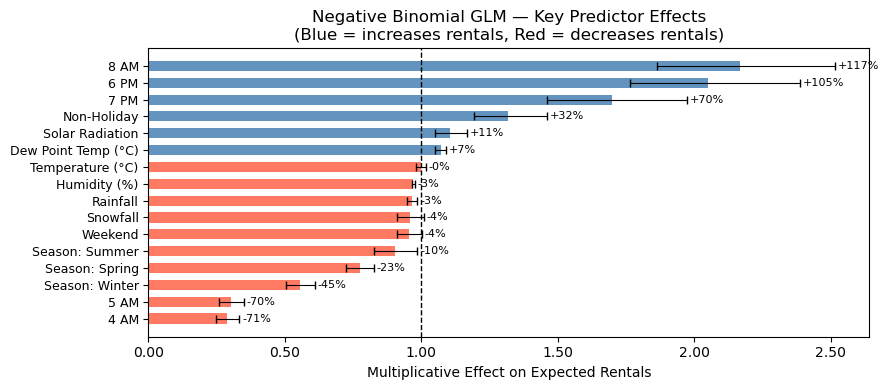

In [70]:
import matplotlib.ticker as mticker

# Selected predictors to display
keep = [
    "Q('Temperature(°C)')",
    "Q('Humidity(%)')",
    "Q('Dew point temperature(°C)')",
    "Q('Solar Radiation (MJ/m2)')",
    "Q('Rainfall(mm)')",
    "Q('Snowfall (cm)')",
    "C(Seasons)[T.Spring]",
    "C(Seasons)[T.Summer]",
    "C(Seasons)[T.Winter]",
    "C(Holiday)[T.No Holiday]",
    "Weekend",
    "C(Hour)[T.8]",
    "C(Hour)[T.18]",
    "C(Hour)[T.19]",
    "C(Hour)[T.4]",
    "C(Hour)[T.5]",
]

# Cleaner labels for plotting
label_map = {
    "Q('Temperature(°C)')":            "Temperature (°C)",
    "Q('Humidity(%)')":                "Humidity (%)",
    "Q('Dew point temperature(°C)')":  "Dew Point Temp (°C)",
    "Q('Solar Radiation (MJ/m2)')":    "Solar Radiation",
    "Q('Rainfall(mm)')":               "Rainfall",
    "Q('Snowfall (cm)')":              "Snowfall",
    "C(Seasons)[T.Spring]":            "Season: Spring",
    "C(Seasons)[T.Summer]":            "Season: Summer",
    "C(Seasons)[T.Winter]":            "Season: Winter",
    "C(Holiday)[T.No Holiday]":        "Non-Holiday",
    "Weekend":                         "Weekend",
    "C(Hour)[T.8]":                    "8 AM",
    "C(Hour)[T.18]":                   "6 PM",
    "C(Hour)[T.19]":                   "7 PM",
    "C(Hour)[T.4]":                    "4 AM",
    "C(Hour)[T.5]":                    "5 AM",
}

# Convert coefficients and confidence intervals to multiplicative effects
ci = nb_model.conf_int()

plot_df = pd.DataFrame({
    "Effect": np.exp(nb_model.params[keep]),
    "Lower":  np.exp(ci.loc[keep, 0]),
    "Upper":  np.exp(ci.loc[keep, 1]),
    "pvalue": nb_model.pvalues[keep]
}).rename(index=label_map)

# Sort from smallest to largest effect
plot_df = plot_df.sort_values("Effect")

# Error bar widths
xerr = [
    plot_df["Effect"] - plot_df["Lower"],
    plot_df["Upper"] - plot_df["Effect"]
]

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(plot_df))

# Blue = increase, Red = decrease
colors = ["steelblue" if x >= 1 else "tomato" for x in plot_df["Effect"]]

ax.barh(
    y,
    plot_df["Effect"],
    xerr=xerr,
    color=colors,
    alpha=0.85,
    height=0.6,
    capsize=3,
    error_kw={"linewidth": 0.8}
)

# Add percentage labels
for i, (effect, upper) in enumerate(zip(plot_df["Effect"], plot_df["Upper"])):
    pct = (effect - 1) * 100
    ax.text(
        upper + 0.01,
        i,
        f"{pct:+.0f}%",
        va="center",
        fontsize=8
    )

# Reference line for no effect
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)

# Formatting
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.set_xlabel("Multiplicative Effect on Expected Rentals")
ax.set_title(
    "Negative Binomial GLM — Key Predictor Effects\n"
    "(Blue = increases rentals, Red = decreases rentals)"
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.2f}")
)

plt.tight_layout()
plt.show()

### d. Model Diagnostics

We assess the Negative Binomial GLM using four standard diagnostic plots for count-data GLMs.


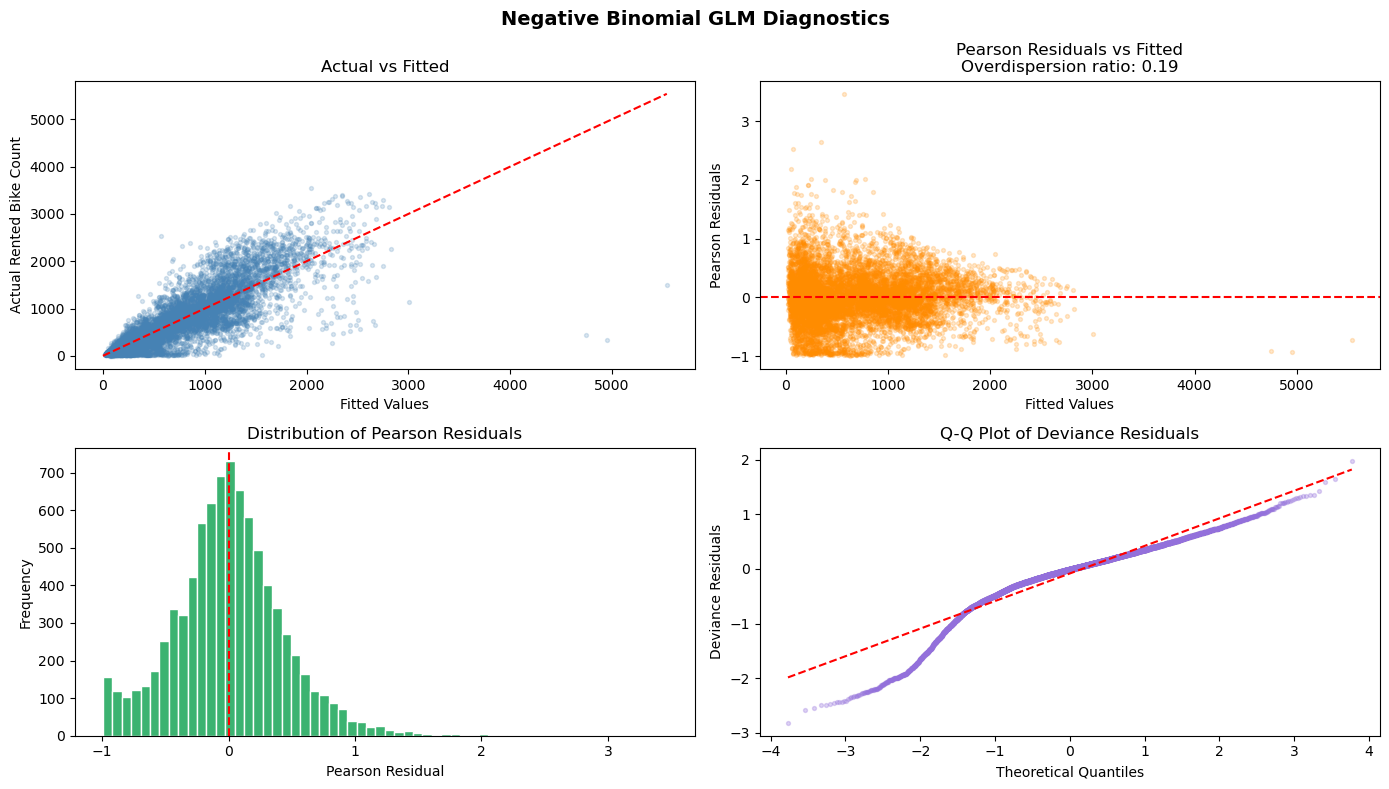

Overdispersion ratio (Pearson χ²/df): 0.19


In [68]:
nb_pearson = nb_model.resid_pearson
nb_deviance = nb_model.resid_deviance
nb_fitted = nb_model.fittedvalues
nb_overdispersion = nb_model.pearson_chi2 / nb_model.df_resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].scatter(nb_fitted, df_glm['Rented Bike Count'], alpha=0.2, s=8, color='steelblue')
lims = [0, max(df_glm['Rented Bike Count'].max(), nb_fitted.max())]
axes[0, 0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Actual Rented Bike Count')
axes[0, 0].set_title('Actual vs Fitted')

axes[0, 1].scatter(nb_fitted, nb_pearson, alpha=0.2, s=8, color='darkorange')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Pearson Residuals')
axes[0, 1].set_title(f'Pearson Residuals vs Fitted\nOverdispersion ratio: {nb_overdispersion:.2f}')

axes[1, 0].hist(nb_pearson, bins=60, color='mediumseagreen', edgecolor='white')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Pearson Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Pearson Residuals')

(osm, osr), (slope, intercept, _) = stats.probplot(nb_deviance, dist='norm')
axes[1, 1].scatter(osm, osr, alpha=0.3, s=8, color='mediumpurple')
axes[1, 1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Deviance Residuals')
axes[1, 1].set_title('Q-Q Plot of Deviance Residuals')

plt.suptitle('Negative Binomial GLM Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Overdispersion ratio (Pearson χ²/df): {nb_overdispersion:.2f}")


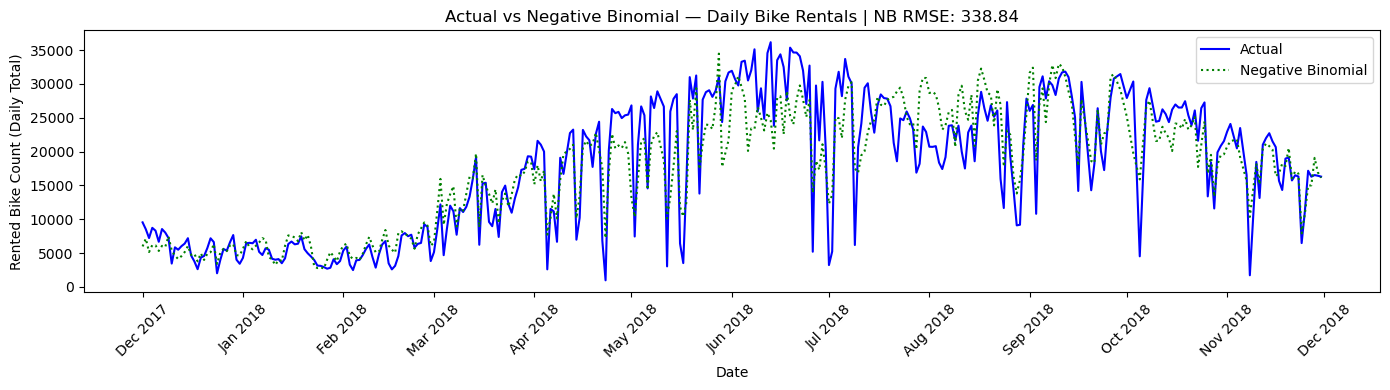

In [69]:
daily = (pd.DataFrame({'Date': df_glm['Date_only'], 'Actual': df_glm['Rented Bike Count'], 'NB': nb_pred})
         .groupby('Date')[['Actual', 'NB']].sum().reset_index().sort_values('Date'))

plt.figure(figsize=(14, 4))
plt.plot(daily['Date'], daily['Actual'], label='Actual', color='blue', linewidth=1.5)
plt.plot(daily['Date'], daily['NB'], label='Negative Binomial', color='green', linewidth=1.5, linestyle=':')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title(f"Actual vs Negative Binomial — Daily Bike Rentals | NB RMSE: {nb_rmse:.2f}")
plt.xlabel("Date")
plt.ylabel("Rented Bike Count (Daily Total)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The diagnostic plots indicate that the Negative Binomial model provides a substantially better fit than the OLS models.

The actual versus fitted plot shows that the model tracks the observed counts closely across most of the range, although some underprediction remains for the largest demand values. The Pearson residuals are centered around zero with no pronounced funnel shape, suggesting that the model adequately accounts for the changing variance in the data.

The histogram of Pearson residuals is concentrated near zero and is much more symmetric than the residual distribution from the OLS model. The Q-Q plot of deviance residuals is also reasonably linear, with only moderate departures in the tails.

Overall, the Negative Binomial GLM captures the main structure of the data while accounting for overdispersion, making it the most appropriate and reliable model considered in this analysis.